In [657]:
import pandas as pd
import numpy as np
from typing import Literal

df = pd.read_excel("../datasets/TABEL DATA LATIH HATESPEECH RISET.xlsx", names=["username", "content", "category"])
df.head()

,username,content,category
0,__succiduous,Udah jelek brengsek pula,Ras
1,KemenagMempawah,"Lucunya penghuni negeri ini selalu di hiasi dan diwarnai Politik identitas,sehingga ada kesan Ã¢â‚¬Å“MABOK AGAMAÃ¢â‚¬Â..ada kaÃ¢â‚¬Â¦ https://t.co/ltlsFqcz4q",Agama
2,1stKOREANguy1,"Yang jelek + miskin udah pasti bukan Kristen , Tapi yang cantik,pinter,jago nuyanyi,Cino jowo jago masak,Kaya, UdahÃ¢â‚¬Â¦ https://t.co/OCiEYgamq0",Ras
3,newsutdofficial,@MurtadhaOne1 Mereka memanfaatkan kebodohan kadrun melalui berita2 hoax,Agama
4,pshycosocial_,orang jelek kalo tarik tambang pasti kalah terus\n \n soalnya ga menarik xixi,Ras


In [658]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2003 entries, 0 to 2002
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   username  2000 non-null   object
 1   content   1999 non-null   object
 2   category  1999 non-null   object
dtypes: object(3)
memory usage: 47.1+ KB


"username" columns is no needed in our machine learning

In [659]:
df.drop(columns=["username"], inplace=True)

check duplicated and missing value

In [660]:
print(f"Duplicated total: {df.duplicated().sum()}")

df.isna().sum()

Duplicated total: 56


content     4
category    4
dtype: int64

Drop duplicated and missing values

In [661]:
df = df.drop_duplicates()
df = df.dropna()

print(f"Duplicated total: {df.duplicated().sum()}")

df.isna().sum()

Duplicated total: 0


content     0
category    0
dtype: int64

In [662]:
df["category"].unique()

array(['Ras', 'Agama', 'Netral'], dtype=object)

View count of category

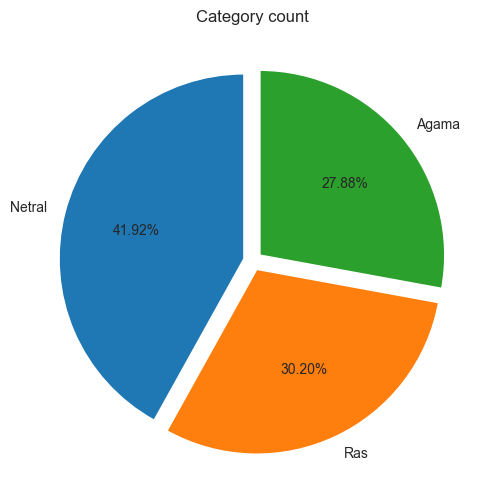

In [663]:
import matplotlib.pyplot as plt

category_data = df["category"].value_counts()

plt.figure(figsize=(6,6))
plt.title("Category count")
plt.pie(
    category_data,
    labels=category_data.keys(),
    autopct="%.2f%%",
    startangle=90,
    explode=(0.05, 0.05, 0.05),
)
plt.show()

Good spread data!

# Pra-preprocessing data

Chane categorical to number

In [664]:
cat_cols_list = {'Ras': 0, 'Agama': 1, 'Netral': 2}
cat_cols_list_reversed = {v:k for k, v in cat_cols_list.items()}

df["category"] = df["category"].replace(cat_cols_list)

C:\Users\User\AppData\Local\Temp\ipykernel_7592\2943511328.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["category"] = df["category"].replace(cat_cols_list)


### List

In [665]:
slang_words_list = {
  "lo": "kamu",
  "jln": "jalan",
  "gpp": "tidak apa-apa",
  "btw": "ngomong-ngomong",
  "tp": "tapi",
  "yg": "yang",
  "dmn": "di mana",
  "krn": "karena",
  "tdk": "tidak",
  "td": "tadi",
  "sdh": "sudah",
  "blm": "belum",
  "dkt": "dekat",
  "sy": "saya",
  "gw": "saya",
  "gua": "saya",
  "lu": "kamu",
  "loe": "kamu",
  "km": "kamu",
  "kmu": "kamu",
  "trs": "terus",
  "dr": "dari",
  "dgn": "dengan",
  "sm": "sama",
  "aja": "saja",
  "kpn": "kapan",
  "bsk": "besok",
  "tp": "tapi",
  "jd": "jadi",
  "udh": "sudah",
  "bgt": "banget",
  "pdhl": "padahal",
  "skrg": "sekarang",
  "tdk": "tidak",
  "msh": "masih",
  "bkn": "bukan",
  "kl": "kalau",
  "klu": "kalau",
  "klw": "kalau",
  "jdwl": "jadwal",
  "bbrp": "beberapa",
  "mrk": "mereka",
  "dg": "dengan",
  "hrs": "harus",
  "bs": "bisa",
  "tp": "tapi",
  "spt": "seperti",
  "krn": "karena",
  "bgmn": "bagaimana",
  "gmn": "gimana",
  "blg": "bilang",
  "stlh": "setelah",
  "sblm": "sebelum",
  "sbnrnya": "sebenarnya",
  "klo": "kalau",
  "dlm": "dalam",
  "thn": "tahun",
  "hr": "hari",
  "mnt": "menit",
  "dtk": "detik",
  "trs": "terus",
  "prnh": "pernah",
  "tdr": "tidur",
  "nnti": "nanti",
  "lg": "lagi",
  "mlm": "malam",
  "pgi": "pagi",
  "siang": "siang",
  "sore": "sore",
  "bntar": "sebentar",
  "pke": "pakai",
  "lbh": "lebih",
  "pnting": "penting",
  "gmna": "bagaimana",
  "ok": "oke",
  "okey": "oke",
  "sip": "oke",
  "mantul": "mantap betul",
  "wkwk": "tertawa",
  "haha": "tertawa",
  "hehe": "tertawa",
  "huhu": "sedih",
  "hikss": "sedih",
  "ckck": "tidak percaya",
  "y": "iya",
  "g": "tidak",
  "n": "tidak",
  "ga": "tidak",
  "gak": "tidak",
  "ywdh": "ya sudah",
  "oke": "baik",
  "yaudah": "ya sudah",
  "ayok": "ayo",
  "ayo": "ayo",
  "ntar": "nanti",
  "swt": "mengeluh",
  "woles": "santai",
  "santuy": "santai",
  "mager": "malas gerak",
  "gabut": "tidak ada kerjaan",
  "baper": "terbawa perasaan",
  "sbnr": "sebenarnya",
  "hoax": "berita palsu",
  "cm": "cuma",
  "cma": "cuma",
  "plis": "tolong",
  "pls": "tolong",
  "thx": "terima kasih",
  "tq": "terima kasih",
  "makasih": "terima kasih",
  "makasi": "terima kasih",
  "mksi": "terima kasih",
  "lup": "lupa",
  "ngga": "tidak",
  "cpt": "cepat",
  "lambat": "pelan",
  "kluar": "keluar",
  "msk": "masuk",
  "brg": "barang",
  "org": "orang",
  "tmn": "teman",
  "bgt": "banget",
  "bkin": "bikin",
  "bljr": "belajar",
  "ngomong": "berbicara",
  "brp": "berapa",
  "sbk": "sibuk",
  "prgi": "pergi",
  "tpn": "telepon",
  "sllu": "selalu",
  "mntp": "mantap",
  "brkt": "berangkat",
  "stlh": "setelah",
  "bgitu": "begitu",
  "knpa": "kenapa",
  "knp": "kenapa",
  "bnr": "benar",
  "kyk": "seperti",
  "gaje": "tidak jelas",
  "astagfirullah": "astaga"
}

additional_stopwords = [
  "iya", "nih", "deh", "dong", "gitu", "kan", "tuh", "kayak", "abis", "ntar", "daripada",
  "tadi", "besok", "lusa", "kemarin", "gimana", "gak", "enggak", "nggak", "kok", "mah", "lah",
  "loh", "gue", "gua", "aku", "kamu", "dia", "mereka", "kita", "situ", "saya", "anda", "sampe",
  "banget", "bgt", "gak", "yaudah", "udah", "doang", "juga", "soalnya", "soal", "barusan", "tuh",
  "bakal", "bakalan", "bakalnya", "lagi-lagi", "apalagi", "mending", "pengen", "mau", "emang",
  "kok", "dah", "sama", "emangnya", "tentunya", "lah", "dong", "tadi", "pula", "beneran",
  "nih", "tuh", "tadi", "kagak", "ntar", "ntaran", "giliran", "masa", "sekalian", "nyari",
  "pas", "abis", "aslinya", "ceritanya", "pantes", "syukur", "bjir", "anjir", "haha", "hehe",
  "huhu", "yah", "iye", "ayok", "yuk", "ayo", "nih", "biasa", "biasanya", "malah", "malahan",
  "ketimbang", "bakal", "hampir", "semisal", "terutama", "sebetulnya", "sejatinya", "so",
  "ntaps", "mantap", "bang", "bro", "sis", "gan", "min", "mas", "mbak", "pak", "bu", "bapak",
  "ibu", "om", "tante", "abang", "adik", "kak", "kakak", "aneh", "biasa", "aslinya", "sejujurnya",
  "tau", "tau-tau", "padahal", "toh", "nampaknya", "rupanya", "jadinya", "pastinya", "mestinya",
  "saking", "justru", "jangankan", "barangkali", "sepertinya", "kelihatannya", "makanya",
  "malah", "apaan", "gimana", "gimana sih", "eh", "ya", "ye", "nuh", "dong", "sebenarnya",
  "memang", "yaelah", "weleh", "welehweleh", "welehwelehweleh", "btw", "btw,", "cmiiw",
  "cmiiw,", "imho", "imho,", "kayaknya", "kayak", "gitu", "gini", "giliran", "lho", "lbh",
  "drpd", "bgt", "dgn", "yg", "tsb", "blm", "pdhl", "krn", "klo", "sdh", "dll", "dsb",
  "utk", "ttp", "tdk", "kpd", "smg", "alhamdulillah", "masyaallah", "insyaallah", "astaga",
  "aduuh", "eits", "lah", "lho", "waduh", "weleh", "yaudahlah"
]

## Cleaning text

In [666]:
from nltk.corpus import stopwords, wordnet
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
import re

class CleaningText():
    def     __init__(
            self,
            inline:bool=False,
            output_type:Literal["list", "text"] = "list",
            need_stem=True
    ):
        self.inline = inline
        self.output_type = output_type
        self.need_stem = need_stem

        id_stopwords = set(stopwords.words("indonesian"))
        en_stopwords = set(stopwords.words("english"))
        id_stopwords.update(en_stopwords)
        id_stopwords.update(additional_stopwords)
        self.stopwords_list = id_stopwords

    def _basic_cleaning(self, text:str)->list[str]:
        text = re.sub(r"@[A-Za-z0-9]+", "", text)
        text = re.sub(r"#[A-Za-z0-9]+", "", text)
        text = re.sub(r"\d+", "", text)
        text = re.sub(r"[^\w\s]", "", text)
        text = text.replace("\n", " ").lower().split()
        return text

    def _fix_slang_words(self, words:list[str])->list[str]:
        return [slang_words_list[word] if word in slang_words_list else word for word in words]

    def _remove_stopwords(self, words:list[str])->list[str]:
        return [word for word in words if word not in self.stopwords_list]

    def _stemming_words(self, words:list[str])->list[str]:
        factory = StemmerFactory()
        stemmer = factory.create_stemmer()
        return [stemmer.stem(word) for word in words]

    def _cleaning_text(self, text):
        words = self._basic_cleaning(text)
        words = self._fix_slang_words(words)
        words = self._remove_stopwords(words)
        if self.need_stem:
            words = self._stemming_words(words)
        return words

    def transform(self, text):
        if not self.inline:
            return list(
                self._cleaning_text(txt)
                if self.output_type == "list" else
                " ".join(self._cleaning_text(txt))
                for txt in text
            )
        else:
            return " ".join(self._cleaning_text(text)) if self.output_type == "text" else self._cleaning_text(text)

implements cleaning text

In [667]:
cleaner_text = CleaningText(inline=False, output_type="text", need_stem=False)
df["clean_text"] = cleaner_text.transform(df["content"])

df.head()

,content,category,clean_text
0,Udah jelek brengsek pula,0,jelek brengsek
1,"Lucunya penghuni negeri ini selalu di hiasi dan diwarnai Politik identitas,sehingga ada kesan Ã¢â‚¬Å“MABOK AGAMAÃ¢â‚¬Â..ada kaÃ¢â‚¬Â¦ https://t.co/ltlsFqcz4q",1,lucunya penghuni negeri hiasi diwarnai politik identitassehingga kesan ãâåmabok agamaãââada kaãââ httpstcoltlsfqczq
2,"Yang jelek + miskin udah pasti bukan Kristen , Tapi yang cantik,pinter,jago nuyanyi,Cino jowo jago masak,Kaya, UdahÃ¢â‚¬Â¦ https://t.co/OCiEYgamq0",0,jelek miskin kristen cantikpinterjago nuyanyicino jowo jago masakkaya udahãââ httpstcoocieygamq
3,@MurtadhaOne1 Mereka memanfaatkan kebodohan kadrun melalui berita2 hoax,1,memanfaatkan kebodohan kadrun berita berita palsu
4,orang jelek kalo tarik tambang pasti kalah terus\n \n soalnya ga menarik xixi,0,orang jelek kalo tarik tambang kalah menarik xixi


# Build TF-IDF

In [668]:
from collections import defaultdict

class TF_IDF_Vectorizer():
    def __init__(self, input_is: Literal["text", "list"] = "list"):
        self.input_is = input_is

    def _tf(self, docs):
        TF_Dict = defaultdict(int)

        for term in docs:
            TF_Dict[term] += 1
        return {
            term: count / len(docs) for term, count in TF_Dict.items()
        }

    def _df(self, docs):
        DF_Dict = defaultdict(int)

        for doc in docs:
            unique_term = set(doc)
            for term in unique_term:
                DF_Dict[term] += 1
        return DF_Dict

    def _idf(self, DF_Dict, n_doc):
        return {term: np.log(n_doc / (df + 1)) for term, df in DF_Dict.items()}

    def transform(self, docs):
        if self.input_is == "text":
            if self.input_is == "text":
                docs = [doc.split() for doc in docs] if isinstance(docs, pd.Series) else [docs.split()]

        tf_list = [self._tf(doc) for doc in docs]
        df_dict = self._df(docs)
        idf_dict = self._idf(df_dict, len(docs))

        return [
            {term: tf * idf_dict[term] for term, tf in tf_dict.items()}
            for tf_dict in tf_list
        ]

    def fit_transform(self, docs):
        if self.input_is == "text":
            if self.input_is == "text":
                docs = [doc.split() for doc in docs]\
                    if isinstance(docs, pd.Series) else [docs.split()]

        tf_list = [self._tf(doc) for doc in docs]
        df_dict = self._df(docs)
        self.idf_dict = self._idf(df_dict, len(docs))

        if not hasattr(self, "unique_term"):
            self.unique_term = list(df_dict.keys())

        tf_idf_vector = np.zeros((len(docs), len(self.unique_term)))

        for doc_idx, tf_dict in enumerate(tf_list):
            for term, tf in tf_dict.items():
                if term in self.idf_dict and term in self.unique_term:
                    term_idx = self.unique_term.index(term)
                    tf_idf_vector[doc_idx, term_idx] = tf * self.idf_dict[term]
                    # tf_idf_vector[doc_idx, term_idx] = tf_dict[term]
        return list(tf_idf_vector)

Implements TF-IDF to df

In [669]:
tf_idf = TF_IDF_Vectorizer(input_is="text")
df["TF_IDF"] = tf_idf.transform(df["clean_text"])

df.head()

,content,category,clean_text,TF_IDF
0,Udah jelek brengsek pula,0,jelek brengsek,"{'jelek': 1.0136627702704109, 'brengsek': 3.236945348176137}"
1,"Lucunya penghuni negeri ini selalu di hiasi dan diwarnai Politik identitas,sehingga ada kesan Ã¢â‚¬Å“MABOK AGAMAÃ¢â‚¬Â..ada kaÃ¢â‚¬Â¦ https://t.co/ltlsFqcz4q",1,lucunya penghuni negeri hiasi diwarnai politik identitassehingga kesan ãâåmabok agamaãââada kaãââ httpstcoltlsfqczq,"{'lucunya': 0.4969220893821903, 'penghuni': 0.5394908913626895, 'negeri': 0.3999928552317169, 'hiasi': 0.5732796503717033, 'diwarnai': 0.5732796503717033, 'politik': 0.457755120278379, 'identitassehingga': 0.5732796503717033, 'kesan': 0.5732796503717033, 'ãâåmabok': 0.5732796503717033, 'agamaãââada': 0.5732796503717033, 'kaãââ': 0.5155173853250411, 'httpstcoltlsfqczq': 0.5732796503717033}"
2,"Yang jelek + miskin udah pasti bukan Kristen , Tapi yang cantik,pinter,jago nuyanyi,Cino jowo jago masak,Kaya, UdahÃ¢â‚¬Â¦ https://t.co/OCiEYgamq0",0,jelek miskin kristen cantikpinterjago nuyanyicino jowo jago masakkaya udahãââ httpstcoocieygamq,"{'jelek': 0.2027325540540822, 'miskin': 0.5174607712222014, 'kristen': 0.4799914262780603, 'cantikpinterjago': 0.687935580446044, 'nuyanyicino': 0.687935580446044, 'jowo': 0.6473890696352275, 'jago': 0.687935580446044, 'masakkaya': 0.687935580446044, 'udahãââ': 0.687935580446044, 'httpstcoocieygamq': 0.687935580446044}"
3,@MurtadhaOne1 Mereka memanfaatkan kebodohan kadrun melalui berita2 hoax,1,memanfaatkan kebodohan kadrun berita berita palsu,"{'memanfaatkan': 1.1465593007434065, 'kebodohan': 1.078981782725379, 'kadrun': 0.5911918823808725, 'berita': 1.6214842613060578, 'palsu': 0.915510240556758}"
4,orang jelek kalo tarik tambang pasti kalah terus\n \n soalnya ga menarik xixi,0,orang jelek kalo tarik tambang kalah menarik xixi,"{'orang': 0.29675074421931985, 'jelek': 0.2534156925676027, 'kalo': 0.39123146606625847, 'tarik': 0.8092363370440343, 'tambang': 0.8599194755575549, 'kalah': 0.7453831340732855, 'menarik': 0.7453831340732855, 'xixi': 0.8599194755575549}"


Save TF-IDF vector to df

In [670]:
df["TF-IDF Vector"] = tf_idf.fit_transform(df["clean_text"])
df.head()

,content,category,clean_text,TF_IDF,TF-IDF Vector
0,Udah jelek brengsek pula,0,jelek brengsek,"{'jelek': 1.0136627702704109, 'brengsek': 3.236945348176137}","[3.236945348176137, 1.0136627702704109, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...]"
1,"Lucunya penghuni negeri ini selalu di hiasi dan diwarnai Politik identitas,sehingga ada kesan Ã¢â‚¬Å“MABOK AGAMAÃ¢â‚¬Â..ada kaÃ¢â‚¬Â¦ https://t.co/ltlsFqcz4q",1,lucunya penghuni negeri hiasi diwarnai politik identitassehingga kesan ãâåmabok agamaãââada kaãââ httpstcoltlsfqczq,"{'lucunya': 0.4969220893821903, 'penghuni': 0.5394908913626895, 'negeri': 0.3999928552317169, 'hiasi': 0.5732796503717033, 'diwarnai': 0.5732796503717033, 'politik': 0.457755120278379, 'identitassehingga': 0.5732796503717033, 'kesan': 0.5732796503717033, 'ãâåmabok': 0.5732796503717033, 'agamaãââada': 0.5732796503717033, 'kaãââ': 0.5155173853250411, 'httpstcoltlsfqczq': 0.5732796503717033}","[0.0, 0.0, 0.5732796503717033, 0.5732796503717033, 0.5732796503717033, 0.5732796503717033, 0.3999928552317169, 0.5394908913626895, 0.5732796503717033, 0.5732796503717033, 0.457755120278379, 0.5732796503717033, 0.4969220893821903, 0.5155173853250411, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...]"
2,"Yang jelek + miskin udah pasti bukan Kristen , Tapi yang cantik,pinter,jago nuyanyi,Cino jowo jago masak,Kaya, UdahÃ¢â‚¬Â¦ https://t.co/OCiEYgamq0",0,jelek miskin kristen cantikpinterjago nuyanyicino jowo jago masakkaya udahãââ httpstcoocieygamq,"{'jelek': 0.2027325540540822, 'miskin': 0.5174607712222014, 'kristen': 0.4799914262780603, 'cantikpinterjago': 0.687935580446044, 'nuyanyicino': 0.687935580446044, 'jowo': 0.6473890696352275, 'jago': 0.687935580446044, 'masakkaya': 0.687935580446044, 'udahãââ': 0.687935580446044, 'httpstcoocieygamq': 0.687935580446044}","[0.0, 0.2027325540540822, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.687935580446044, 0.6473890696352275, 0.687935580446044, 0.687935580446044, 0.687935580446044, 0.687935580446044, 0.4799914262780603, 0.5174607712222014, 0.687935580446044, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...]"
3,@MurtadhaOne1 Mereka memanfaatkan kebodohan kadrun melalui berita2 hoax,1,memanfaatkan kebodohan kadrun berita berita palsu,"{'memanfaatkan': 1.1465593007434065, 'kebodohan': 1.078981782725379, 'kadrun': 0.5911918823808725, 'berita': 1.6214842613060578, 'palsu': 0.915510240556758}","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.5911918823808725, 1.078981782725379, 1.1465593007434065, 1.6214842613060578, 0.915510240556758, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 

# Splitting data

In [671]:
def train_test_split(X, y, test_size=0.2, random_state=None):
    if random_state:
        np.random.seed(random_state)
    X, y = np.array(X), np.array(y)

    n_samples = X.shape[0]

    shuffle_indices = np.random.permutation(np.arange(n_samples))

    test_size = round((test_size + 0.1) * n_samples)
    train_size = n_samples - test_size

    train_indices = shuffle_indices[:train_size]
    test_indices = shuffle_indices[train_size:]

    X_train, X_test = X[train_indices], X[test_indices]
    y_train, y_test = y[train_indices], y[test_indices]

    return [X_train.tolist(), X_test.tolist(), y_train.tolist(), y_test.tolist()]

In [672]:
train = [1.2, 2.1, 3.5, 4.4, 5.1, 6.3]
test = [0,0,0,1,1,1]

train_test_split(train, test, test_size=0.3)

[[6.3, 5.1, 2.1, 1.2], [3.5, 4.4], [1, 1, 0, 0], [0, 1]]

In [673]:
from sklearn.model_selection import train_test_split as train_test_split2

train_test_split2(train, test, test_size=0.3)

[[2.1, 3.5, 1.2, 5.1], [6.3, 4.4], [0, 0, 0, 1], [1, 1]]

In [674]:
df["TF-IDF Vector"].loc[1]

array([0.        , 0.        , 0.57327965, ..., 0.        , 0.        ,
       0.        ])

split

In [675]:
X_train, X_test, y_train, y_test = train_test_split(
    df["TF-IDF Vector"],
    df.category,
    random_state=42
)

In [676]:
X_train[0]

array([0., 0., 0., ..., 0., 0., 0.])

In [677]:
X_train[43]

array([0., 0., 0., ..., 0., 0., 0.])

# Modeling

In [678]:
X_train[0][1].sum()

0.0

In [679]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Evaluation

In [680]:
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.62      0.05      0.10       186
           1       0.86      0.04      0.07       153
           2       0.42      0.98      0.59       244

    accuracy                           0.44       583
   macro avg       0.64      0.36      0.26       583
weighted avg       0.60      0.44      0.30       583



# Test predict with data training sample

In [681]:
df.tail()

,content,category,clean_text,TF_IDF,TF-IDF Vector
1997,@feidy_rm Sepertinya diundang..tpi sejauh ramalan dan prediksi tongkat kecamatan belum ada donatur tuk beliin baju adat Jawa..,2,_rm diundangtpi ramalan prediksi tongkat kecamatan donatur tuk beliin baju adat jawa,"{'_rm': 0.5732796503717033, 'diundangtpi': 0.5732796503717033, 'ramalan': 0.5732796503717033, 'prediksi': 0.5732796503717033, 'tongkat': 0.5732796503717033, 'kecamatan': 0.5732796503717033, 'donatur': 0.5732796503717033, 'tuk': 0.5394908913626895, 'beliin': 0.5732796503717033, 'baju': 0.42396636126936527, 'adat': 0.3033897793580049, 'jawa': 0.40537106532651446}","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...]"
1999,"Kurang Ajar memang orang CINA itu, sudah hidup numpang, pelit lagi. ga pernah berkontribusi pada bangsa",0,ajar orang cina hidup numpang pelit berkontribusi bangsa,"{'ajar': 0.7732760779875617, 'orang': 0.29675074421931985, 'cina': 0.37344193829372657, 'hidup': 0.625944203444856, 'numpang': 0.8599194755575549, 'pelit': 0.8599194755575549, 'berkontribusi': 0.8599194755575549, 'bangsa': 0.5659975684121201}","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.29675074421931985, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...]"
2000,"Nah ini paham wahabi semakin merebak di sekitar kita. Memahami agama hanya secara tekstual, pokoknya bidah bidah bidah. suka mengkafirkan orang lain",1,paham wahabi merebak memahami agama tekstual pokoknya bidah bidah bidah suka mengkafirkan orang,"{'paham': 0.3413083668531719, 'wahabi': 0.4979915920270981, 'merebak': 0.5291812157277261, 'memahami': 0.5291812157277261, 'agama': 0.11659376706090462, 'tekstual': 0.5291812157277261, 'pokoknya': 0.4979915920270981, 'bidah': 1.4939747760812943, 'suka': 0.30473731325970466, 'mengkafirkan': 0.5291812157277261, 'orang': 0.18261584259650454}","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.18261584259650454, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.30473731325970466, 0.0, 0.0, 0.0, 0.0, 0.0, 0.4979915920270981, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...]"
2001,"Kita hidup di negara pancasila, harus mengplementasikan sila pancasila yaitu persatuan indonesia. Toh, kita ini memang dari awal beda suku dan agama",2,hidup negara pancasila mengplementasikan sila pancasila persatuan indonesia beda suku agama,"{'hidup': 0.4552321479598953, 'negara': 0.3364819976465903, 'pancasila': 1.0510442755986054, 'mengplementasikan': 0.6253959822236763, 'sila': 0.6253959822236763, 'persatuan': 0.5623826021727721, 'indonesia': 0.3309706683905508, 'beda': 0.3403510535028445, 'suku': 0.3994953776974945, 'agama': 0.1377926337992509}","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,

In [690]:
test_text = df.loc[1997]["content"]
# test_text = "@memefess ras terkuat di bumi"
test_text

'@feidy_rm Sepertinya diundang..tpi sejauh ramalan dan prediksi tongkat kecamatan belum ada donatur tuk beliin baju adat Jawa..'

In [691]:
cleaner = CleaningText(inline=True, output_type="text", need_stem=False)

clean_text = cleaner.transform(test_text)
vec_text = tf_idf.fit_transform(clean_text)

prediction = model.predict([X_train[43]])
prediction

array([0])